In [3]:
from datasets import load_dataset
from google import genai
import pandas as pd
import os
import time
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
from transformers import pipeline

c:\Programming\Outpeer\capstone_proj\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
raw_df = pd.read_csv("../data/09_kazparc_valid_kk_ru.csv")

df = raw_df.iloc[500:1000]

In [5]:
df["traditional_translation"] = None

df.head()

,id,source_lang,target_lang,domain,pair,traditional_translation
500,LD076715LD,Жеке тұлғалардың және лауазымды адамдардың Қаз...,Неисполнение и (или) ненадлежащее исполнение ф...,legal_docs,kk_ru,None
501,MM111400MM,Ол тек сол пікірталасты тарылтып және назарын ...,Однако он позволяет сузить и сфокусировать эти...,mass_media,kk_ru,None
502,LD002609LD,"Туберкулезбен ауыратын, қылмыстық-атқару жүйес...","Принудительное лечение гражданина, больного ту...",legal_docs,kk_ru,None
503,GN069967GN,"Ерлер ырғасып сынады, есерлер былғасып сынады.","Герои падают покачиваясь, дурни падают очерняя...",general,kk_ru,None
504,FI018310FI,"Бірақ ондай адамдарға күн көрсетпеді, оларды қ...","Но этим людям ходу не давали, их преследовали.",fiction,kk_ru,None


In [6]:
client = genai.Client()

for m in client.models.list():
    print(m.name)

models/gemini-2.5-flash
models/gemini-2.5-pro
models/gemini-2.0-flash
models/gemini-2.0-flash-001
models/gemini-2.0-flash-lite-001
models/gemini-2.0-flash-lite
models/gemini-2.5-flash-preview-tts
models/gemini-2.5-pro-preview-tts
models/gemma-4-26b-a4b-it
models/gemma-4-31b-it
models/gemini-flash-latest
models/gemini-flash-lite-latest
models/gemini-pro-latest
models/gemini-2.5-flash-lite
models/gemini-2.5-flash-image
models/gemini-3-pro-preview
models/gemini-3-flash-preview
models/gemini-3.1-pro-preview
models/gemini-3.1-pro-preview-customtools
models/gemini-3.1-flash-lite-preview
models/gemini-3.1-flash-lite
models/gemini-3-pro-image-preview
models/nano-banana-pro-preview
models/gemini-3.1-flash-image-preview
models/lyria-3-clip-preview
models/lyria-3-pro-preview
models/gemini-3.1-flash-tts-preview
models/gemini-robotics-er-1.5-preview
models/gemini-robotics-er-1.6-preview
models/gemini-2.5-computer-use-preview-10-2025
models/deep-research-max-preview-04-2026
models/deep-research-prev

Series([], Name: traditional_translation, dtype: object)

In [7]:
system_prompt = """
Сен — креативті қазақ редакторысың. Саған берілген орысша сөйлемнің астарына (subtext) үңіл де, қазақ тілінде сөйлейтін адам осы ойды күнделікті өмірде қалай айтар еді, солай жазып бер.
Ереже:

Сөзбе-сөз аудармаға қатал тыйым салынады.

Егер орысша етістік қазақшаға калька болып тұрса (мысалы, 'принять решение' -> 'шешім қабылдау'), оны мағынасына сай 'бел байлау' немесе 'түйіндеу' деп өзгерт.

Жауап қысқа, нұсқа және табиғи болуы тиіс.

Рабиға Сыздық апамыздың еңбетеріндегі ережелерді қолданғаның дұрыс

Тек қазақша нұсқасын қайтарып бер. Орысшасы керек емес

Артық дым керегі жоқ. Тек таза аудармаларды жазып бер
"""

def translate_traditional_batch(russian_list):
    combined_text = "\n".join(russian_list)
    try:
        response = client.models.generate_content(
            model="gemini-3.1-flash-lite-preview",
            contents=f"{system_prompt}\n\nМәтіндер:\n{combined_text}"
        )

        # 1. Жауаптың мәтіні бар-жоғын тексеру
        if response.text:
            raw_text = response.text.strip()
        else:
            # Кейде жауап candidates ішінде болады
            raw_text = response.candidates[0].content.parts[0].text.strip()

        translations = [line.strip() for line in raw_text.split('\n') if line.strip()]
        
        # 2. Егер ИИ 10 жолдың орнына аз қайтарса, бос орындармен толтыру
        while len(translations) < len(russian_list):
            translations.append("Аударма табылмады")
            
        return translations[:len(russian_list)] # Артық болса кесіп тастау

    except Exception as e:
        print(f"Қате орын алды: {e}")
        # Егер қате болса, None орнына бос тізім қайтару бағанға жазу үшін маңызды
        return ["Қате: Аударылмады"] * len(russian_list)
    
batch_size = 10
for i in range(0, len(df), batch_size):
    batch_end = min(i + batch_size, len(df))
    russian_batch = df['target_lang'][i:batch_end].tolist()
    
    print(f"Өңделуде: {i}-{batch_end} жолдар...")
    
    translated_batch = translate_traditional_batch(russian_batch)
    
    # Егер ИИ қайтарған тізім ұзындығы сәйкес келсе, жазамыз
    if len(translated_batch) == len(russian_batch):
        df.loc[500+i:500+batch_end-1, 'traditional_translation'] = translated_batch
    else:
        # Сәйкес келмесе, сақтық үшін бір-бірлеп аударуға көшуге болады
        print(f"Ескерту: {i} блогында сәйкессіздік. Қайта тексеріңіз.")

    # API лимитін сақтау (Тегін нұсқа үшін 4 секунд күту)
    time.sleep(4)

    # Прогресті жоғалтпау үшін әр 50 жол сайын сақтап отыру
    if batch_end % 50 == 0:
        df.to_csv('500_kazparc_in_progress.csv', index=False)


Өңделуде: 0-10 жолдар...
Өңделуде: 10-20 жолдар...
Қате орын алды: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}
Өңделуде: 20-30 жолдар...
Өңделуде: 30-40 жолдар...
Өңделуде: 40-50 жолдар...
Өңделуде: 50-60 жолдар...
Өңделуде: 60-70 жолдар...
Өңделуде: 70-80 жолдар...
Өңделуде: 80-90 жолдар...
Өңделуде: 90-100 жолдар...
Өңделуде: 100-110 жолдар...
Өңделуде: 110-120 жолдар...
Өңделуде: 120-130 жолдар...
Өңделуде: 130-140 жолдар...
Өңделуде: 140-150 жолдар...
Өңделуде: 150-160 жолдар...
Өңделуде: 160-170 жолдар...
Өңделуде: 170-180 жолдар...
Өңделуде: 180-190 жолдар...
Өңделуде: 190-200 жолдар...
Өңделуде: 200-210 жолдар...
Өңделуде: 210-220 жолдар...
Өңделуде: 220-230 жолдар...
Өңделуде: 230-240 жолдар...
Өңделуде: 240-250 жолдар...
Өңделуде: 250-260 жолдар...
Өңделуде: 260-270 жолдар...
Өңделуде: 270-280 жолдар...
Өңделуде: 280-290 жолдар.

In [10]:
df.to_csv('../data/final_result_500_1000.csv', index=False)
print("Барлық жұмыс аяқталды және файл сақталды!")

Барлық жұмыс аяқталды және файл сақталды!


Строчки 90-100 не заполнились. Заполняю их отдельно

In [31]:
df = pd.read_csv("../data/500_kazparc_500_1000.csv")

start_idx = 440
end_idx = 450

# Тек осы ауқымды өңдеу
for i in range(start_idx, end_idx, batch_size):
    batch_end = min(i + batch_size, len(df))
    russian_batch = df['target_lang'][i:batch_end].tolist()
    
    print(f"Өңделуде: {i}-{batch_end} жолдар...")
    
    # Қате болған жағдайда бірнеше рет қайталап көру (retry logic)
    attempts = 0
    translated_batch = None
    
    while attempts < 3:
        translated_batch = translate_traditional_batch(russian_batch)
        # Егер сәтті аударылса және None болмаса, циклден шығамыз
        if translated_batch and all(x is not None for x in translated_batch):
            break
        attempts += 1
        print(f"Қайта көру ({attempts}/3)... Модель бос емес.")
        time.sleep(10) # 503 қатесінде ұзағырақ күткен дұрыс
    
    # Нәтижені жазу
    if translated_batch and len(translated_batch) == len(russian_batch):
        df.loc[i:batch_end-1, 'traditional_translation'] = translated_batch
        print(f"{i}-{batch_end} жолдар сәтті толтырылды.")
    else:
        print(f"Қате: {i} блогын аудару мүмкін болмады.")

# Түзетілген нәтижені сақтау
df.to_csv('../data/500_kazparc_500_1000.csv', index=False)

Өңделуде: 440-450 жолдар...
440-450 жолдар сәтті толтырылды.


In [37]:
df_0_500 = pd.read_csv("../data/500_kazparc_90_100_fixed.csv")
df_500_1000 = pd.read_csv("../data/500_kazparc_500_1000.csv")

final_df = pd.concat([df_0_500, df_500_1000], ignore_index=True)

final_df.to_csv("../data/final_kk_ru_trad.csv", index=False)

In [39]:
trad_df = pd.read_csv("../data/500_kazparc_90_100_fixed.csv")

In [40]:
trad_df["length_calque"] = trad_df["source_lang"].str.split().str.len()
trad_df["length_traditional"] = trad_df["traditional_translation"].str.split().str.len()

print(f"Average length of sentences with calque: {trad_df['length_calque'].mean():.2f}")
print(f"Average length of sentences without calque: {trad_df['length_traditional'].mean():.2f}")

Average length of sentences with calque: 12.35
Average length of sentences without calque: 9.85


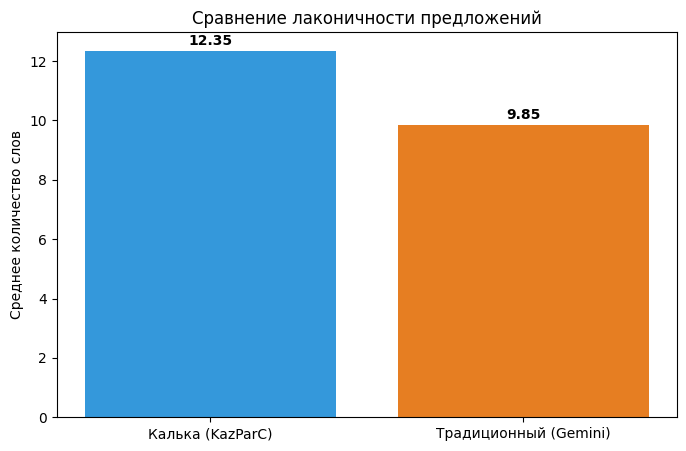

In [17]:
labels = ['Калька (KazParC)', 'Традиционный (Gemini)']
averages = [12.35, 9.85]

plt.figure(figsize=(8, 5))
plt.bar(labels, averages, color=['#3498db', '#e67e22'])
plt.ylabel('Среднее количество слов')
plt.title('Сравнение лаконичности предложений')

# Добавляем подписи цифр над столбцами
for i, v in enumerate(averages):
    plt.text(i, v + 0.2, str(v), ha='center', fontweight='bold')

plt.show()

Длина слов в предложениях переведенных на казахский без кальки намного меньше чем у тех где есть калька. Традиционный казахский язык на 20% лаконичнее. Gemini AI не только перевел с русского на казахский но и убрал "словесный жир", делая текст более натуральным.

НО: В некоторых случаях это приводило к потери некоторой части информации. Хоть Gemini и сделал текст более лаконичным но в некоторых случаях мог менять смысл написанного

In [ ]:
#Collecting all words from both traditional and source columns
words_calque = set(" ".join(trad_df["source_lang"]).lower().split())
words_trad = set(" ".join(trad_df["traditional_translation"]).lower().split())

# Words that disappeareed (they were in calque, but disappeared in traditional)
disappeared = words_calque - words_trad

# Words that appeared (New words)
appeared = words_trad - words_calque

print(f"An example of words that have disappeared (potential calque): {list(disappeared)[:10]}")

An example of words that have disappeared (potential calque): ['тоқтата', 'болатыны', 'сыңарымен', 'жоғы', 'қаққанына', 'биылғы', 'аптасы', 'сыналған.', 'жәшіктері', 'жарнама']


Хоть и пропажа некоторых слов может показаться странной но если углубиться то они правильные. Допустим пропажа слова "немере" можно обосновать тем что в оригинале она использовалась в контексте "немере аға". В казахском языке для этого есть слово "бөле". Так что вместо 

"Менің немере ағам оны маған ұсынды, мен оны сынап көрдім."

Получилось 

"Бөлем кеңес бергесін, байқап көрдім."

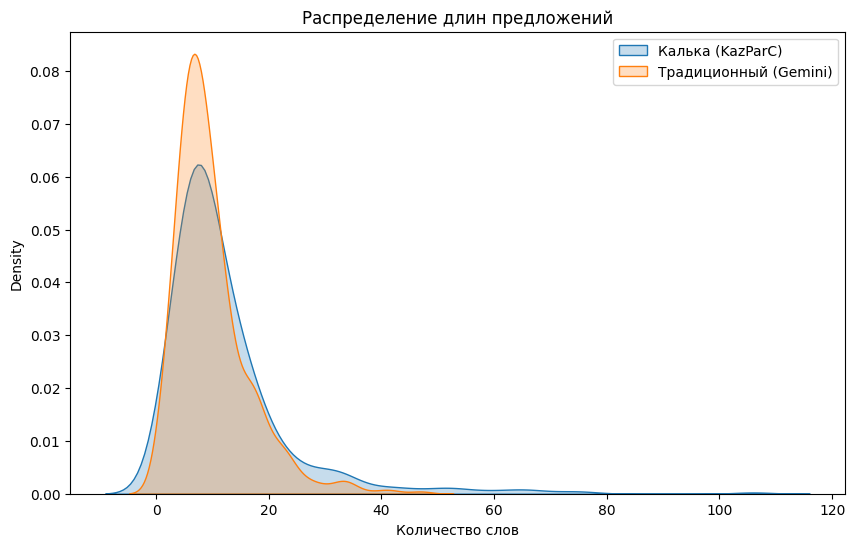

In [ ]:
plt.figure(figsize=(10, 6))
sns.kdeplot(trad_df["length_calque"], label="Калька (KazParC)", fill=True)
sns.kdeplot(trad_df["length_traditional"], label="Традиционный (Gemini)", fill=True)
plt.title("Распределение длин предложений")
plt.xlabel("Количество слов")
plt.legend()
plt.show()

Этот график доказывает что громоздкие кальки в более короткие и естественные структуры.

У кальки (Синего график) более длинный хвост, уходящий за 60-100 слов. Это свойственно для канцелярских или плохо переведенных текстов. Традиционный вариант (оранжевый график) хвост почти полностью исчезает после 40 слов, что говорит о лучшей структурированности.

Данные для оранжевого графика стали более однородными что хорошо для будущих моделей

In [ ]:
def get_tokens(text_list):
    tokens = []
    for text in text_list:
        words = re.findall(r"\b\w+\b", str(text).lower())
        tokens.extend(words)
    return tokens

tokens_calque = get_tokens(trad_df["source_lang"])
tokens_trad = get_tokens(trad_df["traditional_translation"])

counter_calque = Counter(tokens_calque)
counter_trad = Counter(tokens_trad)

difference = {}
for word in counter_calque:
    diff = counter_calque[word] - counter_trad.get(word, 0)
    if diff > 0:
        difference[word] = diff

top_dropped = sorted(difference.items(), key= lambda x: x[1], reverse=True)[:10]
print("Топ исчезнувших слов (потенциальные маркеры калек):")
for word, count in top_dropped:
    print(f"{word}: -{count} раз")

Топ исчезнувших слов (потенциальные маркеры калек):
және: -44 раз
бойынша: -25 раз
қазақстан: -24 раз
осы: -23 раз
туралы: -17 раз
бір: -14 раз
үшін: -13 раз
бар: -12 раз
жүзеге: -12 раз
салықтық: -12 раз


"және: -44 раз"
Избыточное использование союза "и" пример классической кальки с русского языка. В естественном казахском языке предложения часто связываются деепричастиями или перечислениями.

"бойынша: -25 раз" и "туралы: -17 раз"
Злоупотребление послелогами "по" и "о". Их исчезновение говорит о том что структура предложений была перестроена в естественные падежные формы.

"жүзеге: -12 раз"
Это часть конструкции "жүзеге асыру"
В традиционном казахском такие обороты заменяются прямыми глаголами.

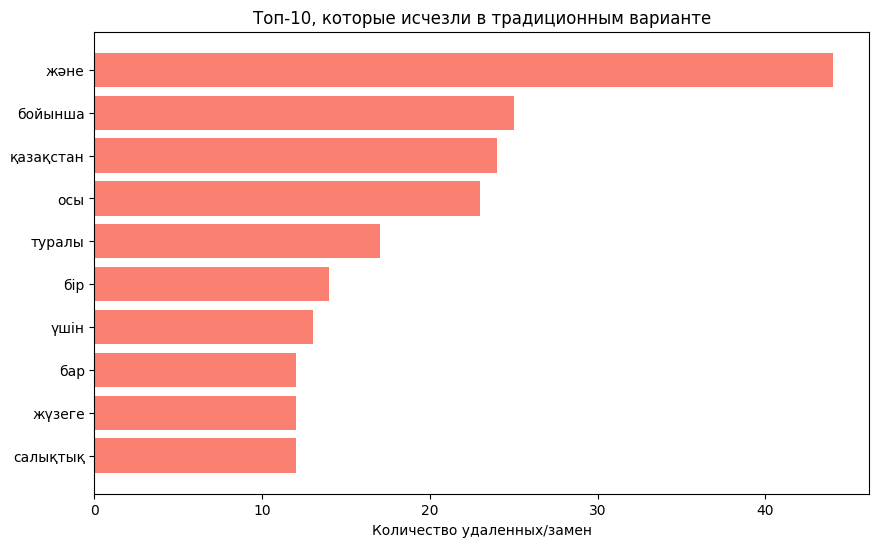

In [8]:
words, counts = zip(*top_dropped)
counts = [abs(c) for c in counts]

plt.figure(figsize=[10, 6])
plt.barh(words, counts, color = "salmon")
plt.xlabel("Количество удаленных/замен")
plt.title("Топ-10, которые исчезли в традиционным варианте")
plt.gca().invert_yaxis()
plt.show()

In [41]:
final_df["length_calque"] = final_df["source_lang"].str.split().str.len()
final_df["length_traditional"] = final_df["traditional_translation"].str.split().str.len()

print(f"Average length of sentences with calque: {final_df['length_calque'].mean():.2f}")
print(f"Average length of sentences without calque: {final_df['length_traditional'].mean():.2f}")

Average length of sentences with calque: 12.82
Average length of sentences without calque: 10.00


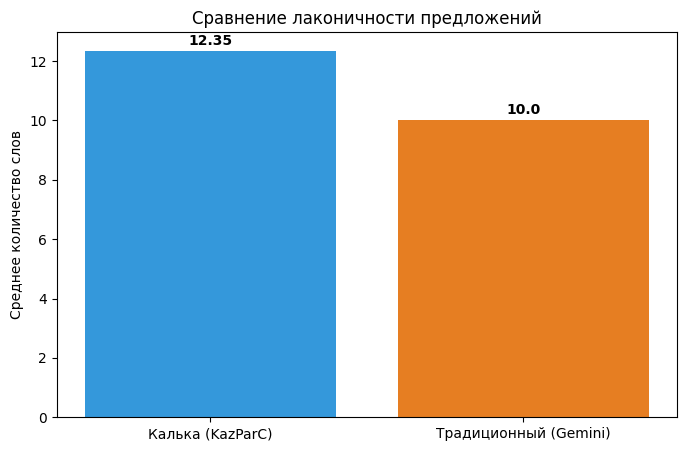

In [42]:
labels = ['Калька (KazParC)', 'Традиционный (Gemini)']
averages = [12.35, 10.00]

plt.figure(figsize=(8, 5))
plt.bar(labels, averages, color=['#3498db', '#e67e22'])
plt.ylabel('Среднее количество слов')
plt.title('Сравнение лаконичности предложений')

# Добавляем подписи цифр над столбцами
for i, v in enumerate(averages):
    plt.text(i, v + 0.2, str(v), ha='center', fontweight='bold')

plt.show()

In [43]:
#Collecting all words from both traditional and source columns
words_calque = set(" ".join(final_df["source_lang"]).lower().split())
words_trad = set(" ".join(final_df["traditional_translation"]).lower().split())

# Words that disappeareed (they were in calque, but disappeared in traditional)
disappeared = words_calque - words_trad

# Words that appeared (New words)
appeared = words_trad - words_calque

print(f"An example of words that have disappeared (potential calque): {list(disappeared)[:10]}")

An example of words that have disappeared (potential calque): ['басшы,', 'заңнамасы', 'беру,', 'жәрдемақы,', 'аймақтық', '(алдын', 'когнитивті', 'градус', 'шкафтар', 'қайтарып.']


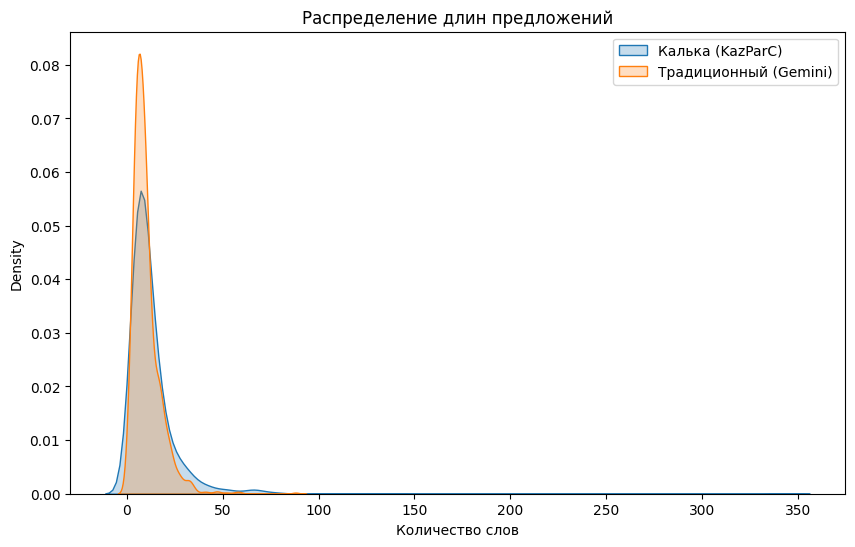

In [45]:
plt.figure(figsize=(10, 6))
sns.kdeplot(final_df["length_calque"], label="Калька (KazParC)", fill=True)
sns.kdeplot(final_df["length_traditional"], label="Традиционный (Gemini)", fill=True)
plt.title("Распределение длин предложений")
plt.xlabel("Количество слов")
plt.legend()
plt.show()

In [47]:
def get_tokens(text_list):
    tokens = []
    for text in text_list:
        words = re.findall(r"\b\w+\b", str(text).lower())
        tokens.extend(words)
    return tokens

tokens_calque = get_tokens(final_df["source_lang"])
tokens_trad = get_tokens(final_df["traditional_translation"])

counter_calque = Counter(tokens_calque)
counter_trad = Counter(tokens_trad)

difference = {}
for word in counter_calque:
    diff = counter_calque[word] - counter_trad.get(word, 0)
    if diff > 0:
        difference[word] = diff

top_dropped = sorted(difference.items(), key= lambda x: x[1], reverse=True)[:10]
print("Топ исчезнувших слов (потенциальные маркеры калек):")
for word, count in top_dropped:
    print(f"{word}: -{count} раз")

Топ исчезнувших слов (потенциальные маркеры калек):
және: -99 раз
туралы: -53 раз
осы: -52 раз
бойынша: -51 раз
қазақстан: -49 раз
бар: -32 раз
бір: -31 раз
жүзеге: -29 раз
республикасының: -28 раз
немесе: -27 раз


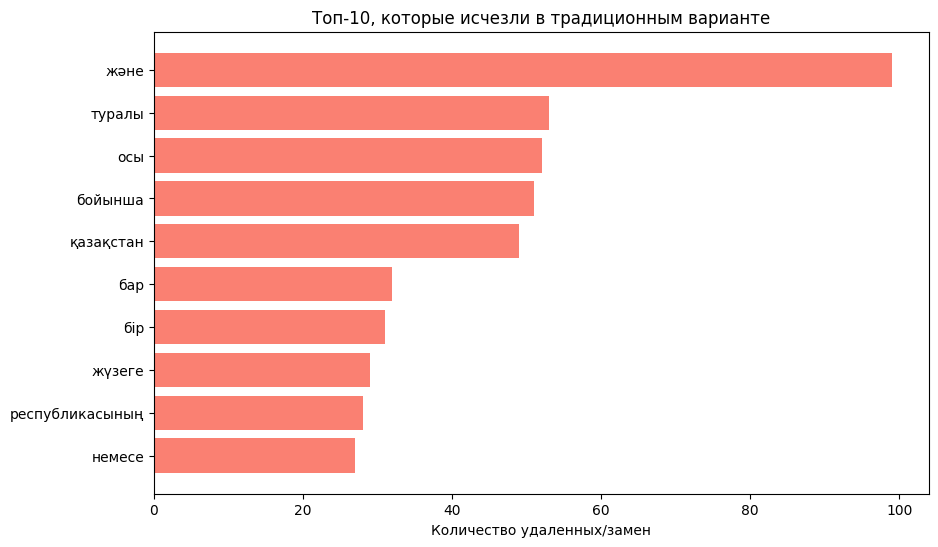

In [48]:
words, counts = zip(*top_dropped)
counts = [abs(c) for c in counts]

plt.figure(figsize=[10, 6])
plt.barh(words, counts, color = "salmon")
plt.xlabel("Количество удаленных/замен")
plt.title("Топ-10, которые исчезли в традиционным варианте")
plt.gca().invert_yaxis()
plt.show()